In [1]:
# ---------- Step 0: Install packages & imports ----------
!pip install -q scikit-learn pandas matplotlib seaborn joblib imbalanced-learn xgboost shap

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, precision_recall_curve)
import joblib

print("Libraries imported. Ready to go.")


Libraries imported. Ready to go.


In [2]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/heart_attack_china.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

# Step 3: Quick overview of dataframe structure
TARGET_COL = 'Heart_Attack'   # change if different

print("Columns list:")
print(df.columns.tolist())
print("\nShape:", df.shape)
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head(30))

# show first 5 rows to eyeball
df.head()


Columns list:
['Patient_ID', 'Age', 'Gender', 'Smoking_Status', 'Hypertension', 'Diabetes', 'Obesity', 'Cholesterol_Level', 'Air_Pollution_Exposure', 'Physical_Activity', 'Diet_Score', 'Stress_Level', 'Alcohol_Consumption', 'Family_History_CVD', 'Healthcare_Access', 'Rural_or_Urban', 'Region', 'Province', 'Hospital_Availability', 'TCM_Use', 'Employment_Status', 'Education_Level', 'Income_Level', 'Blood_Pressure', 'Chronic_Kidney_Disease', 'Previous_Heart_Attack', 'CVD_Risk_Score', 'Heart_Attack']

Shape: (239266, 28)

Dtypes:
Patient_ID                 int64
Age                        int64
Gender                    object
Smoking_Status            object
Hypertension              object
Diabetes                  object
Obesity                   object
Cholesterol_Level         object
Air_Pollution_Exposure    object
Physical_Activity         object
Diet_Score                object
Stress_Level              object
Alcohol_Consumption       object
Family_History_CVD        object
Health

,Patient_ID,Age,Gender,Smoking_Status,Hypertension,Diabetes,Obesity,Cholesterol_Level,Air_Pollution_Exposure,Physical_Activity,...,Hospital_Availability,TCM_Use,Employment_Status,Education_Level,Income_Level,Blood_Pressure,Chronic_Kidney_Disease,Previous_Heart_Attack,CVD_Risk_Score,Heart_Attack
0,1,55,Male,Non-Smoker,No,No,Yes,Normal,High,High,...,Low,Yes,Unemployed,Primary,Low,104,Yes,No,78,No
1,2,66,Female,Smoker,Yes,No,No,Low,Medium,High,...,High,No,Unemployed,Secondary,Middle,142,No,No,49,No
2,3,69,Female,Smoker,No,No,No,Low,Medium,High,...,Low,No,Unemployed,Primary,High,176,No,No,31,No
3,4,45,Female,Smoker,No,Yes,No,Normal,Medium,Low,...,Medium,Yes,Employed,Primary,Low,178,No,Yes,23,No
4,5,39,Female,Smoker,No,No,No,Normal,Medium,Medium,...,Low,No,Retired,Higher,Middle,146,Yes,No,79,No


In [4]:
# Step 4: Convert numeric-like strings to numeric and normalize target to binary 0/1
# We'll try to coerce columns that look numeric but stored as object.
for col in df.columns:
    if df[col].dtype == 'object':
        # try to convert to numeric, but keep if many non-numeric
        conv = pd.to_numeric(df[col].str.replace(',','').str.strip(), errors='coerce')
        if conv.notna().sum() / len(conv) > 0.6:
            df[col] = conv

# Normalize target Heart_Attack to 0/1 if needed
if df[TARGET_COL].dtype == 'object' or df[TARGET_COL].dtype.name == 'category':
    df[TARGET_COL] = df[TARGET_COL].astype(str).str.lower().map(
        lambda v: 1 if v in ['1','yes','y','true','t','positive','attack','heart attack'] else 0)

# If still non-numeric — show unique values for manual mapping
if not np.issubdtype(df[TARGET_COL].dtype, np.number):
    print("Unique target values (please map manually):", df[TARGET_COL].unique())

print("Dtypes after coercion:")
print(df.dtypes)


Dtypes after coercion:
Patient_ID                 int64
Age                        int64
Gender                    object
Smoking_Status            object
Hypertension              object
Diabetes                  object
Obesity                   object
Cholesterol_Level         object
Air_Pollution_Exposure    object
Physical_Activity         object
Diet_Score                object
Stress_Level              object
Alcohol_Consumption       object
Family_History_CVD        object
Healthcare_Access         object
Rural_or_Urban            object
Region                    object
Province                  object
Hospital_Availability     object
TCM_Use                   object
Employment_Status         object
Education_Level           object
Income_Level              object
Blood_Pressure             int64
Chronic_Kidney_Disease    object
Previous_Heart_Attack     object
CVD_Risk_Score             int64
Heart_Attack               int64
dtype: object


In [5]:
# Step 5: Summary statistics for numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", num_cols)

# Show describe()
df[num_cols].describe().T


Numeric columns: ['Patient_ID', 'Age', 'Blood_Pressure', 'CVD_Risk_Score', 'Heart_Attack']


,count,mean,std,min,25%,50%,75%,max
Patient_ID,239266.0,119633.500000,69070.289091,1.0,59817.25,119633.5,179449.75,239266.0
Age,239266.0,59.466284,17.348308,30.0,44.00,59.0,75.00,89.0
Blood_Pressure,239266.0,134.513378,25.991827,90.0,112.00,135.0,157.00,179.0
CVD_Risk_Score,239266.0,54.485581,25.987743,10.0,32.00,54.0,77.00,99.0
Heart_Attack,239266.0,0.121501,0.326709,0.0,0.00,0.0,0.00,1.0


In [6]:
# Step 6: Categorical columns value counts (top 10)
cat_cols = df.select_dtypes(include=['object','category','bool']).columns.tolist()
print("Categorical columns:", cat_cols)

for c in cat_cols:
    print(f"\nColumn: {c}  - unique: {df[c].nunique()}")
    print(df[c].value_counts(dropna=False).head(10))


Categorical columns: ['Gender', 'Smoking_Status', 'Hypertension', 'Diabetes', 'Obesity', 'Cholesterol_Level', 'Air_Pollution_Exposure', 'Physical_Activity', 'Diet_Score', 'Stress_Level', 'Alcohol_Consumption', 'Family_History_CVD', 'Healthcare_Access', 'Rural_or_Urban', 'Region', 'Province', 'Hospital_Availability', 'TCM_Use', 'Employment_Status', 'Education_Level', 'Income_Level', 'Chronic_Kidney_Disease', 'Previous_Heart_Attack']

Column: Gender  - unique: 2
Gender
Female    119948
Male      119318
Name: count, dtype: int64

Column: Smoking_Status  - unique: 2
Smoking_Status
Non-Smoker    119697
Smoker        119569
Name: count, dtype: int64

Column: Hypertension  - unique: 2
Hypertension
No     174557
Yes     64709
Name: count, dtype: int64

Column: Diabetes  - unique: 2
Diabetes
No     212794
Yes     26472
Name: count, dtype: int64

Column: Obesity  - unique: 2
Obesity
No     167521
Yes     71745
Name: count, dtype: int64

Column: Cholesterol_Level  - unique: 3
Cholesterol_Level
No

In [7]:
# Step 7: Missing value detail and percent
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)
miss_pct = (miss / len(df) * 100).round(2)
pd.concat([miss, miss_pct.rename('percent')], axis=1).rename(columns={0:'missing_count'})


,missing_count,percent
Education_Level,59617,24.92


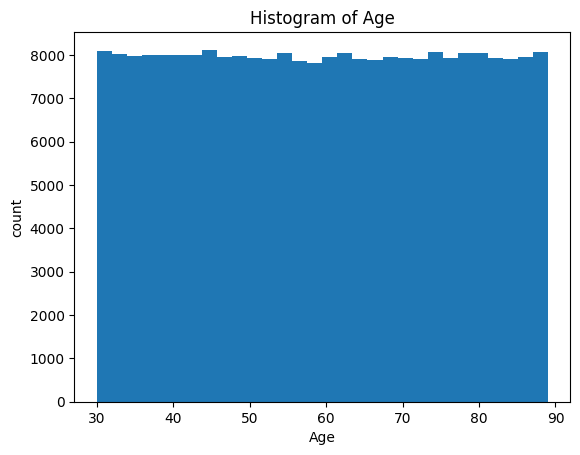

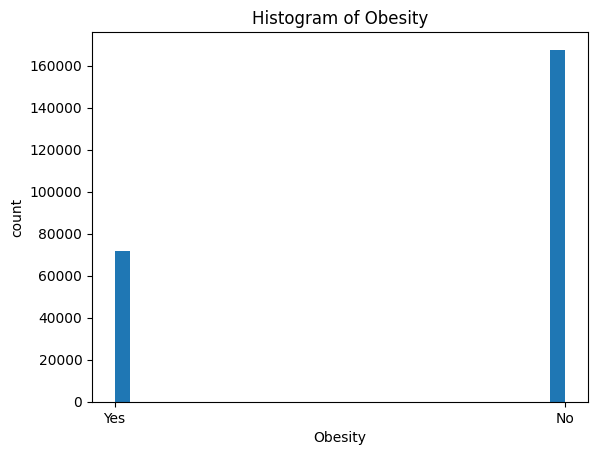

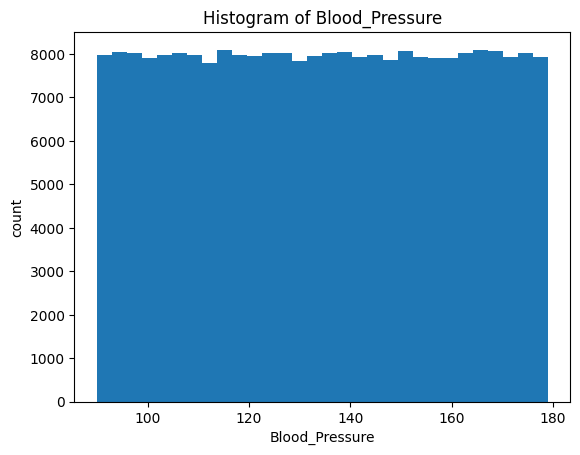

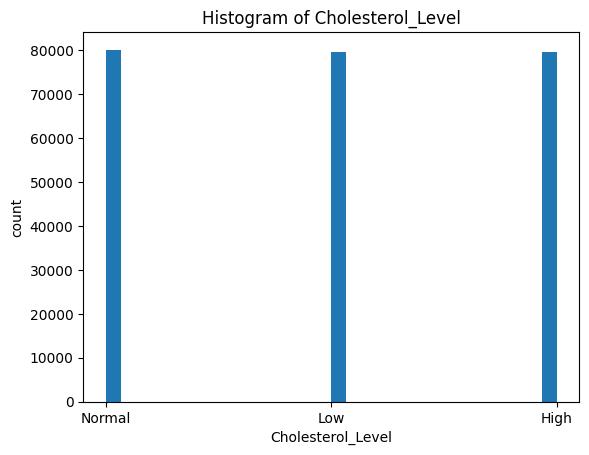

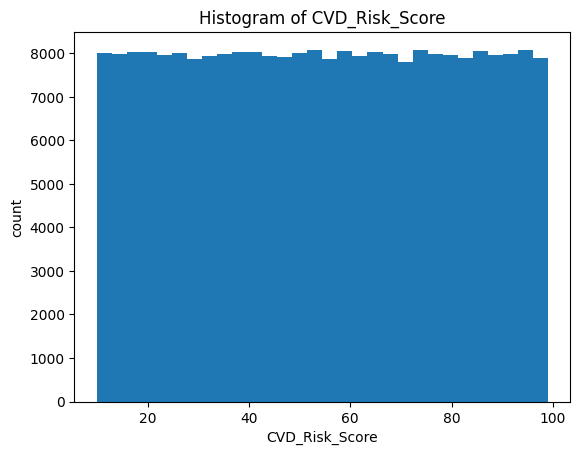

In [8]:
# Step 8: Plot histograms for selected numeric variables
# We'll plot Age, BMI-ish proxies (Obesity), Blood_Pressure, Cholesterol_Level, CVD_Risk_Score
plot_cols = ['Age','Obesity','Blood_Pressure','Cholesterol_Level','CVD_Risk_Score']
plot_cols = [c for c in plot_cols if c in df.columns]

for c in plot_cols:
    plt.figure()
    plt.hist(df[c].dropna(), bins=30)
    plt.title(f'Histogram of {c}')
    plt.xlabel(c)
    plt.ylabel('count')
    plt.show()


In [9]:
# Step 9: Target distribution
print("Target (Heart_Attack) distribution:")
print(df[TARGET_COL].value_counts(dropna=False))
print("\nProportion:")
print(df[TARGET_COL].value_counts(normalize=True))


Target (Heart_Attack) distribution:
Heart_Attack
0    210195
1     29071
Name: count, dtype: int64

Proportion:
Heart_Attack
0    0.878499
1    0.121501
Name: proportion, dtype: float64



Feature: Age
                 count       mean        std   min   25%   50%   75%   max
Heart_Attack                                                              
0             210195.0  59.474055  17.342587  30.0  44.0  59.0  75.0  89.0
1              29071.0  59.410099  17.389813  30.0  44.0  59.0  75.0  89.0


<Figure size 640x480 with 0 Axes>

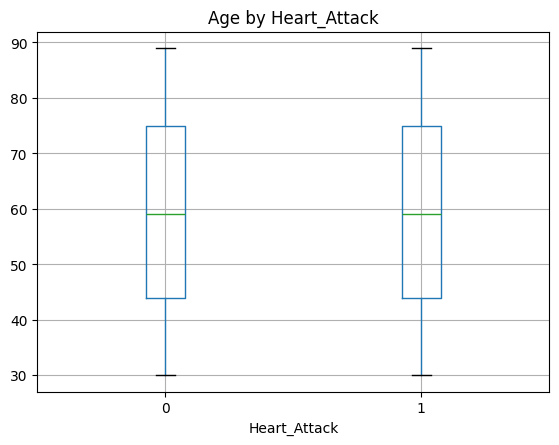


Feature: Blood_Pressure
                 count        mean        std   min    25%    50%    75%  \
Heart_Attack                                                               
0             210195.0  134.508185  25.999703  90.0  112.0  135.0  157.0   
1              29071.0  134.550927  25.935219  90.0  112.0  135.0  157.0   

                max  
Heart_Attack         
0             179.0  
1             179.0  


<Figure size 640x480 with 0 Axes>

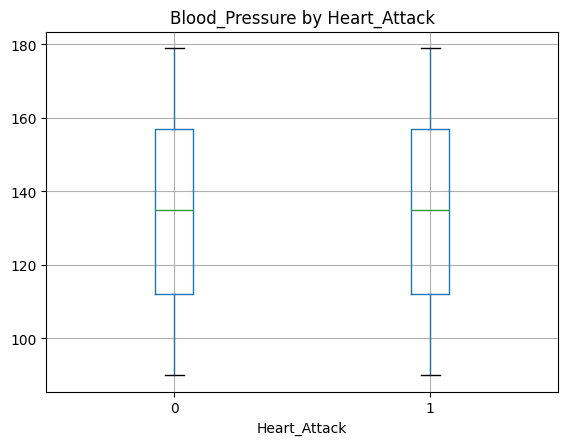


Feature: Cholesterol_Level
                 count      mean       std  min  25%  50%  75%  max
Heart_Attack                                                       
0             210195.0  1.999039  0.815688  1.0  1.0  2.0  3.0  3.0
1              29071.0  2.009184  0.815243  1.0  1.0  2.0  3.0  3.0


<Figure size 640x480 with 0 Axes>

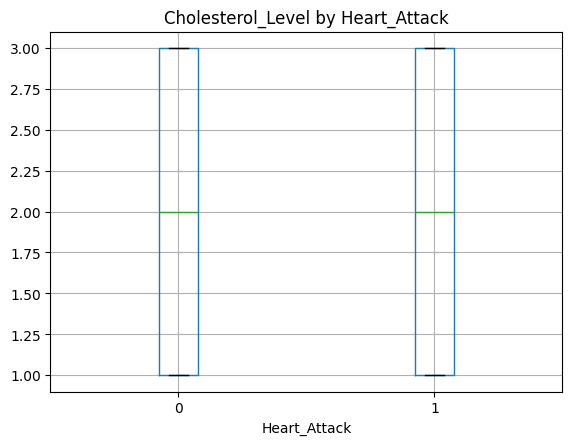


Feature: CVD_Risk_Score
                 count       mean        std   min   25%   50%   75%   max
Heart_Attack                                                              
0             210195.0  54.509460  25.984509  10.0  32.0  54.0  77.0  99.0
1              29071.0  54.312924  26.010909  10.0  32.0  54.0  77.0  99.0


<Figure size 640x480 with 0 Axes>

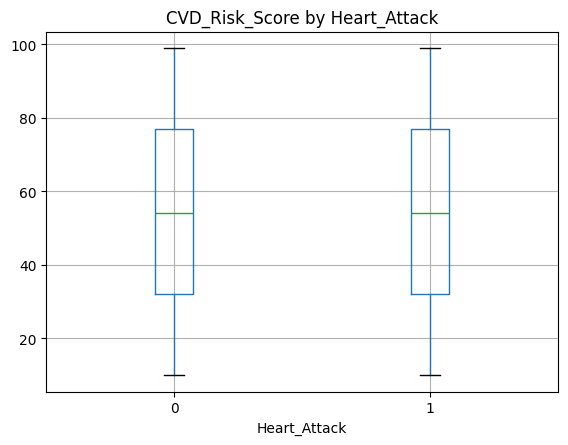


Feature: Physical_Activity
               count unique  top   freq
Heart_Attack                           
0             210195      3  Low  70308
1              29071      3  Low   9778


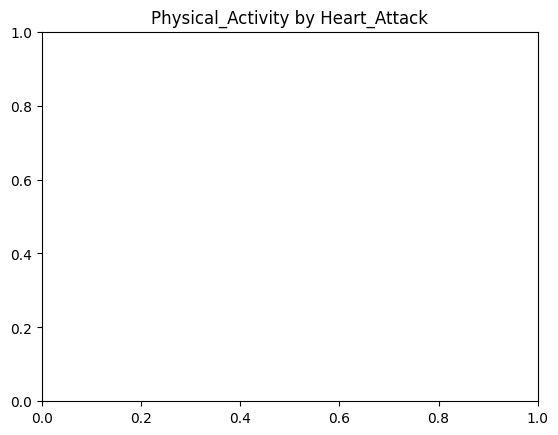

In [10]:
# Step 10: Compare numeric features against target using group stats and boxplot
num_cols = [c for c in num_cols if c != TARGET_COL]
for c in ['Age','Blood_Pressure','Cholesterol_Level','CVD_Risk_Score','Physical_Activity']:
    if c in df.columns:
        print("\nFeature:", c)
        # Handle Cholesterol_Level specifically as it's currently object type but has ordered categories
        if c == 'Cholesterol_Level':
            cholesterol_mapping = {'Low': 1, 'Normal': 2, 'High': 3}
            df[c+'_numeric'] = df[c].map(cholesterol_mapping)
            print(df.groupby(TARGET_COL)[c+'_numeric'].describe())
            plt.figure()
            df.boxplot(column=c+'_numeric', by=TARGET_COL)
        elif pd.api.types.is_numeric_dtype(df[c]): # Only plot if numeric
            print(df.groupby(TARGET_COL)[c].describe())
            plt.figure()
            df.boxplot(column=c, by=TARGET_COL)
        else: # For non-numeric columns in the list, just print the group stats
            print(df.groupby(TARGET_COL)[c].describe())


        plt.suptitle('')
        plt.title(f'{c} by {TARGET_COL}')
        plt.show()

In [11]:
# Step 11: Categorical features vs target - show percent heart attacks per category
# We'll run for a selected set of categorical columns
cat_check = ['Gender','Smoking_Status','Hypertension','Diabetes','Obesity','Family_History_CVD','Rural_or_Urban','Employment_Status','Education_Level']
cat_check = [c for c in cat_check if c in df.columns]

for c in cat_check:
    print("\nCategory:", c)
    tmp = df.groupby(c)[TARGET_COL].agg(['count','sum'])
    tmp['heart_attack_rate'] = (tmp['sum'] / tmp['count']).round(4)
    tmp = tmp.sort_values('heart_attack_rate', ascending=False)
    display(tmp.reset_index().head(20))



Category: Gender


,Gender,count,sum,heart_attack_rate
0,Female,119948,14624,0.1219
1,Male,119318,14447,0.1211



Category: Smoking_Status


,Smoking_Status,count,sum,heart_attack_rate
0,Non-Smoker,119697,14598,0.122
1,Smoker,119569,14473,0.121



Category: Hypertension


...

,Rural_or_Urban,count,sum,heart_attack_rate
0,Urban,95759,11712,0.1223
1,Rural,143507,17359,0.1210



Category: Employment_Status


,Employment_Status,count,sum,heart_attack_rate
0,Retired,79872,9909,0.1241
1,Employed,79638,9649,0.1212
2,Unemployed,79756,9513,0.1193



Category: Education_Level


,Education_Level,count,sum,heart_attack_rate
0,Primary,59901,7320,0.1222
1,Higher,59942,7319,0.1221
2,Secondary,59806,7218,0.1207


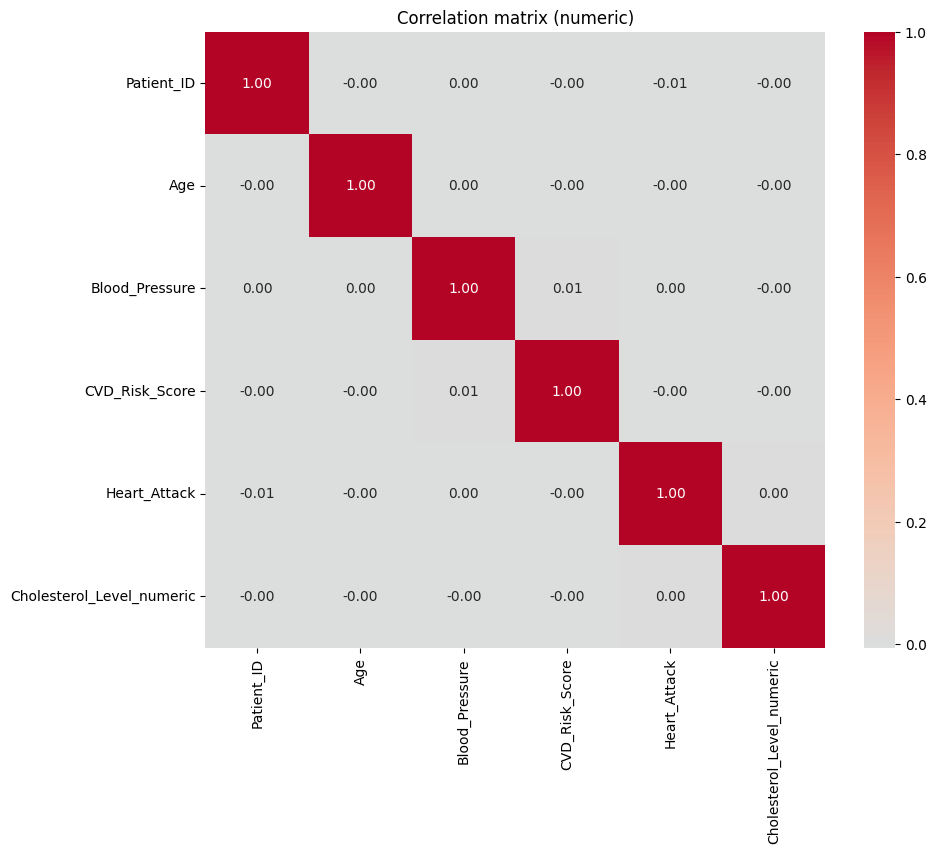

In [12]:
# Step 12: Correlation matrix for numeric variables
import seaborn as sns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix (numeric)')
plt.show()


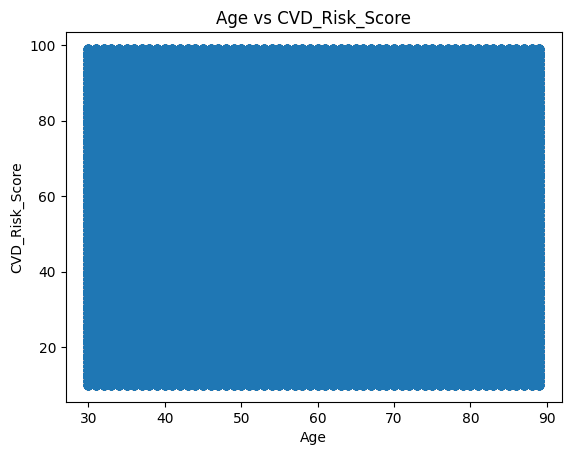

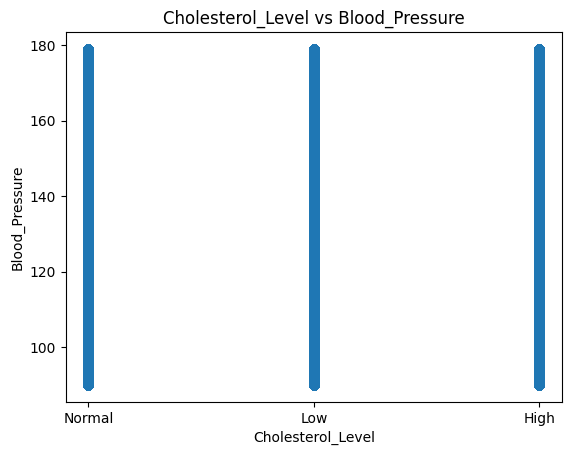

In [13]:
# Step 13: Scatter plots for pairs (Age vs CVD_Risk_Score, Cholesterol vs Blood_Pressure)
pairs = [('Age','CVD_Risk_Score'), ('Cholesterol_Level','Blood_Pressure')]
for a,b in pairs:
    if a in df.columns and b in df.columns:
        plt.figure()
        plt.scatter(df[a], df[b], alpha=0.3)
        plt.xlabel(a); plt.ylabel(b)
        plt.title(f'{a} vs {b}')
        plt.show()


In [14]:
# Step 14: Quick IQR-based outlier counts for numeric columns
outlier_summary = {}
for c in ['Age','Blood_Pressure','Cholesterol_Level','CVD_Risk_Score','Income_Level']:
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
        q1 = df[c].quantile(0.25)
        q3 = df[c].quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5*iqr
        high = q3 + 1.5*iqr
        cnt = df[(df[c] < low) | (df[c] > high)].shape[0]
        outlier_summary[c] = {'outlier_count':cnt, 'total':len(df), 'pct': round(cnt/len(df)*100,2)}
outlier_summary


{'Age': {'outlier_count': 0, 'total': 239266, 'pct': 0.0},
 'Blood_Pressure': {'outlier_count': 0, 'total': 239266, 'pct': 0.0},
 'CVD_Risk_Score': {'outlier_count': 0, 'total': 239266, 'pct': 0.0}}

In [15]:
# Step 15: Example feature engineering - create risk buckets and interaction features
# 1) Age buckets
if 'Age' in df.columns:
    df['Age_bucket'] = pd.cut(df['Age'], bins=[0,30,45,60,120], labels=['<30','30-45','45-60','60+'])

# 2) High_BP flag
if 'Blood_Pressure' in df.columns:
    df['High_BP'] = (df['Blood_Pressure'] > 140).astype(int)

# 3) Smoking + Alcohol combined risk
if 'Smoking_Status' in df.columns and 'Alcohol_Consumption' in df.columns:
    df['smoke_alcohol_risk'] = df['Smoking_Status'].astype(str).str.lower().map(lambda x: 1 if 'yes' in x or 'smoker' in x else 0) + \
                               df['Alcohol_Consumption'].astype(str).str.lower().map(lambda x: 1 if x in ['yes','often','daily'] else 0)

print("Created Age_bucket, High_BP, smoke_alcohol_risk (if columns present).")
df[['Age_bucket','High_BP','smoke_alcohol_risk']].head()


Created Age_bucket, High_BP, smoke_alcohol_risk (if columns present).


,Age_bucket,High_BP,smoke_alcohol_risk
0,45-60,0,2
1,60+,1,1
2,60+,1,1
3,30-45,1,2
4,30-45,1,1


In [19]:
# Step 16: Save a cleaned copy to CSV for modeling
out_name = 'cleaned_health_data.csv'
df.to_csv(out_name, index=False)
print("Saved cleaned file:", out_name)
from google.colab import files
files.download(out_name)   # this triggers browser download


Saved cleaned file: cleaned_health_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
# Step 17: EDA checklist summary
print("""
EDA checklist:
- Missing values inspected (see Step 3 & 7)
- Types coerced and target normalized (Step 4)
- Univariate & bivariate distributions plotted (Step 8-13)
- Outliers scanned (Step 14)
- Example features created (Step 15)
- Cleaned dataset saved (Step 16)
Next: build preprocessing pipeline, handle missing/imputation, encode categorical variables, then model training (LogReg / RandomForest / XGBoost).
""")



EDA checklist:
- Missing values inspected (see Step 3 & 7)
- Types coerced and target normalized (Step 4)
- Univariate & bivariate distributions plotted (Step 8-13)
- Outliers scanned (Step 14)
- Example features created (Step 15)
- Cleaned dataset saved (Step 16)
Next: build preprocessing pipeline, handle missing/imputation, encode categorical variables, then model training (LogReg / RandomForest / XGBoost).



In [21]:
# Cell 1: Imports and basic config. Run this first.
import os
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

# sklearn imports commonly used in later steps
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# classification models (LogReg, RF)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# metrics used in evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report, confusion_matrix, precision_recall_curve, auc)

# XGBoost will be installed/used in its own cell if needed
RANDOM_STATE = 42
print("Imports complete.")


Imports complete.


In [22]:
# Cell 2: Load the cleaned CSV file into df
CLEANED_CSV = 'cleaned_health_data.csv'   # change if your file name is different
if not os.path.exists(CLEANED_CSV):
    raise FileNotFoundError(f"File not found in working directory: {CLEANED_CSV}. Upload or move it to Colab root.")

df = pd.read_csv(CLEANED_CSV)
print("Loaded:", CLEANED_CSV, "Shape:", df.shape)
df.head()


Loaded: cleaned_health_data.csv Shape: (239266, 32)


,Patient_ID,Age,Gender,Smoking_Status,Hypertension,Diabetes,Obesity,Cholesterol_Level,Air_Pollution_Exposure,Physical_Activity,...,Income_Level,Blood_Pressure,Chronic_Kidney_Disease,Previous_Heart_Attack,CVD_Risk_Score,Heart_Attack,Cholesterol_Level_numeric,Age_bucket,High_BP,smoke_alcohol_risk
0,1,55,Male,Non-Smoker,No,No,Yes,Normal,High,High,...,Low,104,Yes,No,78,0,2,45-60,0,2
1,2,66,Female,Smoker,Yes,No,No,Low,Medium,High,...,Middle,142,No,No,49,0,1,60+,1,1
2,3,69,Female,Smoker,No,No,No,Low,Medium,High,...,High,176,No,No,31,0,1,60+,1,1
3,4,45,Female,Smoker,No,Yes,No,Normal,Medium,Low,...,Low,178,No,Yes,23,0,2,30-45,1,2
4,5,39,Female,Smoker,No,No,No,Normal,Medium,Medium,...,Middle,146,Yes,No,79,0,2,30-45,1,1


In [23]:
# Cell 3: Detect numeric and categorical columns automatically
TARGET_COL = 'Heart_Attack'   # change if your target column name differs

if TARGET_COL not in df.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found. Update TARGET_COL variable.")

# Drop ID if present (optional)
for c in ['Patient_ID','id','ID','patient_id']:
    if c in df.columns and c != TARGET_COL:
        df = df.drop(columns=[c])
        print("Dropped ID column:", c)

# Ensure target is 0/1 numeric
if not np.issubdtype(df[TARGET_COL].dtype, np.number):
    df[TARGET_COL] = df[TARGET_COL].astype(str).str.lower().map(
        lambda v: 1 if v in ['1','yes','y','true','t','positive','attack','heart attack'] else 0)

# Feature/target split
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL].astype(int)

numeric_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category','bool']).columns.tolist()

print("Feature shape:", X.shape)
print("Numeric columns:", numeric_cols)
print("Categorical columns:", cat_cols)


Dropped ID column: Patient_ID
Feature shape: (239266, 30)
Numeric columns: ['Age', 'Blood_Pressure', 'CVD_Risk_Score', 'Cholesterol_Level_numeric', 'High_BP', 'smoke_alcohol_risk']
Categorical columns: ['Gender', 'Smoking_Status', 'Hypertension', 'Diabetes', 'Obesity', 'Cholesterol_Level', 'Air_Pollution_Exposure', 'Physical_Activity', 'Diet_Score', 'Stress_Level', 'Alcohol_Consumption', 'Family_History_CVD', 'Healthcare_Access', 'Rural_or_Urban', 'Region', 'Province', 'Hospital_Availability', 'TCM_Use', 'Employment_Status', 'Education_Level', 'Income_Level', 'Chronic_Kidney_Disease', 'Previous_Heart_Attack', 'Age_bucket']


In [24]:
# Cell 4 (Fixed): Build ColumnTransformer preprocessing pipeline (impute, scale, one-hot)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#  Corrected part — replaced 'sparse=False' with 'sparse_output=False'
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

# Test transform shape on a small sample (do not overwrite X)
sample = X.iloc[:5]
Xt_sample = preprocessor.fit_transform(sample)
print(" Preprocessor fitted on sample. Transformed shape example:", Xt_sample.shape)


 Preprocessor fitted on sample. Transformed shape example: (5, 64)


In [25]:
# Cell 5: Train/test split and data checks
from sklearn.model_selection import train_test_split

TARGET_COL = 'Heart_Attack'   # ensure this matches earlier
RANDOM_STATE = 42

# If not already defined in session, reconstruct X,y
if 'X' not in globals() or 'y' not in globals():
    X = df.drop(columns=[TARGET_COL])
    y = df[TARGET_COL].astype(int)

# Quick checks
print("Any NaNs in X (total):", X.isnull().sum().sum())
print("Target distribution:")
print(y.value_counts(), "\nProportions:\n", y.value_counts(normalize=True).round(3))

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("\nShapes -> X_train:", X_train.shape, "X_test:", X_test.shape)
print("Train target proportions:\n", y_train.value_counts(normalize=True).round(3))
print("Test target proportions:\n", y_test.value_counts(normalize=True).round(3))


Any NaNs in X (total): 59617
Target distribution:
Heart_Attack
0    210195
1     29071
Name: count, dtype: int64 
Proportions:
 Heart_Attack
0    0.878
1    0.122
Name: proportion, dtype: float64

Shapes -> X_train: (191412, 30) X_test: (47854, 30)
Train target proportions:
 Heart_Attack
0    0.878
1    0.122
Name: proportion, dtype: float64
Test target proportions:
 Heart_Attack
0    0.879
1    0.121
Name: proportion, dtype: float64


In [26]:
# Cell 6: Logistic Regression pipeline, train & evaluate
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc

# Build pipeline (uses preprocessor defined in Cell 4)
pipe_logreg = Pipeline(steps=[
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE))
])

# Fit
print("Training Logistic Regression...")
pipe_logreg.fit(X_train, y_train)
print("Done.")

# Predict & probabilities
y_pred_lr = pipe_logreg.predict(X_test)
y_prob_lr = pipe_logreg.predict_proba(X_test)[:,1]

# Evaluation helper
def print_eval(y_true, y_pred, y_prob):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc
    print("Accuracy:", round(accuracy_score(y_true,y_pred),4))
    print("Precision:", round(precision_score(y_true,y_pred, zero_division=0),4))
    print("Recall:", round(recall_score(y_true,y_pred, zero_division=0),4))
    print("F1:", round(f1_score(y_true,y_pred, zero_division=0),4))
    print("ROC AUC:", round(roc_auc_score(y_true,y_prob),4))
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    print("PR AUC:", round(auc(rec, prec),4))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true,y_pred))
    print("\nClassification Report:\n", classification_report(y_true,y_pred, zero_division=0))

print("\n=== Logistic Regression Evaluation ===")
print_eval(y_test, y_pred_lr, y_prob_lr)


Training Logistic Regression...
Done.

=== Logistic Regression Evaluation ===
Accuracy: 0.5061
Precision: 0.1214
Recall: 0.4914
F1: 0.1947
ROC AUC: 0.4982
PR AUC: 0.1213

Confusion Matrix:
 [[21361 20679]
 [ 2957  2857]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.51      0.64     42040
           1       0.12      0.49      0.19      5814

    accuracy                           0.51     47854
   macro avg       0.50      0.50      0.42     47854
weighted avg       0.79      0.51      0.59     47854



In [27]:
# Cell 7: Random Forest pipeline, train & evaluate
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline(steps=[
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])

print("Training Random Forest...")
pipe_rf.fit(X_train, y_train)
print("Done.")

y_pred_rf = pipe_rf.predict(X_test)
# Get probabilities (RF supports predict_proba)
y_prob_rf = pipe_rf.predict_proba(X_test)[:,1]

print("\n=== Random Forest Evaluation ===")
print_eval(y_test, y_pred_rf, y_prob_rf)


Training Random Forest...
Done.

=== Random Forest Evaluation ===
Accuracy: 0.8785
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC AUC: 0.5046
PR AUC: 0.1228

Confusion Matrix:
 [[42040     0]
 [ 5814     0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94     42040
           1       0.00      0.00      0.00      5814

    accuracy                           0.88     47854
   macro avg       0.44      0.50      0.47     47854
weighted avg       0.77      0.88      0.82     47854



In [28]:
# Cell 9: Compare ROC AUC on test set and save pipelines to ./models/
import os
os.makedirs('models', exist_ok=True)

models = {'LogisticRegression': pipe_logreg, 'RandomForest': pipe_rf}
if 'pipe_xgb' in globals():
    models['XGBoost'] = pipe_xgb

scores = {}
for name, p in models.items():
    try:
        prob = p.predict_proba(X_test)[:,1]
        scores[name] = roc_auc_score(y_test, prob)
    except Exception as e:
        scores[name] = -1
        print(f"Could not compute ROC AUC for {name}: {e}")

print("ROC AUC scores on test set:", scores)

# Save all pipelines
for name, p in models.items():
    path = f"models/{name}_pipeline.joblib"
    joblib.dump(p, path)
    print("Saved:", path)

# Save best model
best_name = max(scores, key=scores.get)
best_path = f"models/best_model_{best_name}.joblib"
joblib.dump(models[best_name], best_path)
print("Best model:", best_name, "saved to:", best_path)


ROC AUC scores on test set: {'LogisticRegression': np.float64(0.4981992349579757), 'RandomForest': np.float64(0.504574185575878)}
Saved: models/LogisticRegression_pipeline.joblib
Saved: models/RandomForest_pipeline.joblib
Best model: RandomForest saved to: models/best_model_RandomForest.joblib
